In [1]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [2]:
df_merged = pd.read_csv("dataset_forecast.csv")
df_merged["date"] = pd.to_datetime(df_merged["date"], format='ISO8601' )
df_merged = df_merged[(df_merged['date']>'2005-03-01') & (df_merged['date']<='2026-01-01')] # I filter only where I have rows without null values

In [3]:
df_merged.date.min()

Timestamp('2005-04-01 00:00:00')

In [4]:
# df_working_days = pd.read_excel("dataset_working_days_italy.xlsx")
# df_working_days['Date'] = pd.to_datetime(df_working_days['Date'], format='ISO8601' )
# df_working_days.rename(columns={'WorkingDays':'working_days'}, inplace = True)


In [5]:
# df_merged = df_merged.merge(df_working_days, how = 'left', left_on = 'date', right_on = 'Date')

In [6]:
df_merged

,date,workforce,inactives,employment_rate,youth_employment_rate,activity_rate,unemployment_rate,industry_production_prices,services_production_prices,companies_trust,gasoline_car_price,diesel_price,GPL_price,diesel_heatining_price
1,2005-04-01,23905.030,14467.207,57.37,51.60,62.30,7.92,78.3,NaN,93.0,1.21972,1.10630,0.55373,1.02208
2,2005-05-01,23892.852,14491.091,57.62,51.49,62.25,7.44,78.2,NaN,92.2,1.20874,1.07075,0.55322,9974.00000
3,2005-06-01,23955.620,14426.254,57.66,51.79,62.41,7.61,78.6,NaN,89.9,1.20900,1.09044,0.55320,1.03456
4,2005-07-01,23506.991,14874.186,57.19,51.89,61.25,6.62,78.8,NaN,92.2,1.24486,1.13104,0.55342,1.06796
5,2005-08-01,23335.841,15043.225,56.85,49.94,60.80,6.51,79.1,NaN,93.3,1.25586,1.14061,0.55399,1.07425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,2025-09-01,24732.640,12416.623,62.55,44.11,66.58,6.04,123.1,NaN,93.8,1.71024,1.63531,0.69714,1.38680
247,2025-10-01,24712.759,12433.050,62.78,43.28,66.53,5.64,122.8,115.4,94.4,1.69451,1.62232,0.69545,1.38145
248,2025-11-01,24426.135,12718.409,62.13,43.00,65.76,5.52,124.0,NaN,96.0,1.71901,1.68175,0.69413,1.41570
249,2025-12-01,24531.682,12609.532,62.20,43.43,66.05,5.83,123.1,NaN,96.4,1.69686,1.65260,0.69482,1.35576


In [7]:
meadian_comp_trust= df_merged['companies_trust'].median()
meadian_ind_price = df_merged['industry_production_prices'].median()
df_merged['companies_trust'] = df_merged['companies_trust'].fillna(meadian_comp_trust )
df_merged['industry_production_prices'] = df_merged['industry_production_prices'].fillna(meadian_ind_price )

In [8]:
df_merged = df_merged[['date', #'working_days' ,
                         'workforce', 'inactives', 'employment_rate',
                        'youth_employment_rate', 'activity_rate', 'unemployment_rate',
                        'industry_production_prices', 'companies_trust', 'gasoline_car_price',
                        'diesel_price', 'GPL_price', 'diesel_heatining_price']]

# 1. Data Exploration

In [9]:
df_merged[[  'workforce', 'inactives']] = df_merged[[ 'workforce', 'inactives']]*1000

df_merged[[  'workforce', 'inactives']] = df_merged[[  'workforce', 'inactives']].astype(int)

In [10]:
df_merged.head(5)


,date,workforce,inactives,employment_rate,youth_employment_rate,activity_rate,unemployment_rate,industry_production_prices,companies_trust,gasoline_car_price,diesel_price,GPL_price,diesel_heatining_price
1,2005-04-01,23905030,14467207,57.37,51.60,62.30,7.92,78.3,93.0,1.21972,1.10630,0.55373,1.02208
2,2005-05-01,23892852,14491091,57.62,51.49,62.25,7.44,78.2,92.2,1.20874,1.07075,0.55322,9974.00000
3,2005-06-01,23955620,14426254,57.66,51.79,62.41,7.61,78.6,89.9,1.20900,1.09044,0.55320,1.03456
4,2005-07-01,23506991,14874186,57.19,51.89,61.25,6.62,78.8,92.2,1.24486,1.13104,0.55342,1.06796
5,2005-08-01,23335841,15043225,56.85,49.94,60.80,6.51,79.1,93.3,1.25586,1.14061,0.55399,1.07425


In [11]:
numeric = [   #'working_days', 
           'workforce', 'inactives', 'employment_rate',
            'youth_employment_rate', 'activity_rate', 'unemployment_rate',
            'industry_production_prices', 'companies_trust', 'gasoline_car_price',
            'diesel_price', 'GPL_price', 'diesel_heatining_price',  "date"]

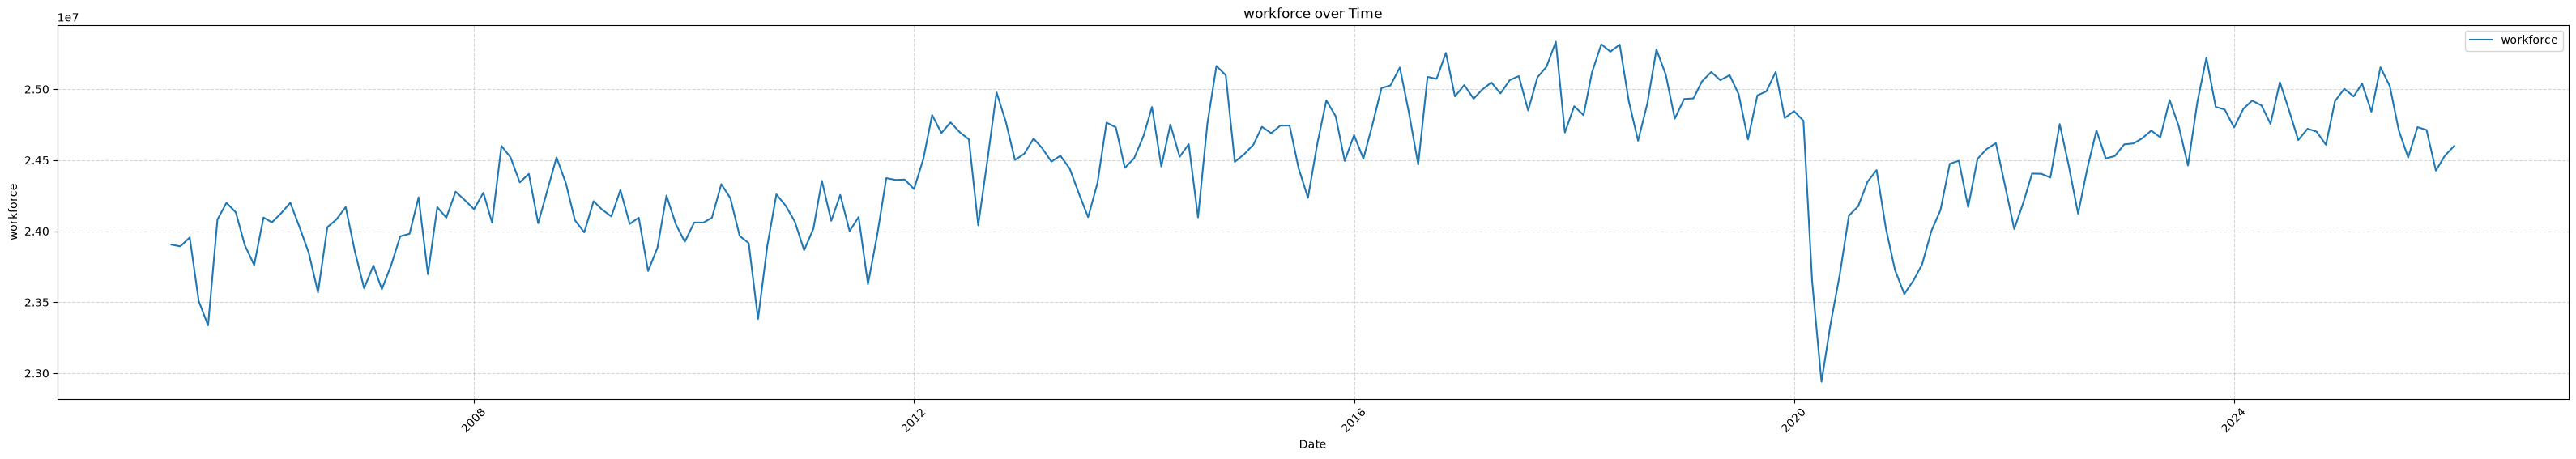

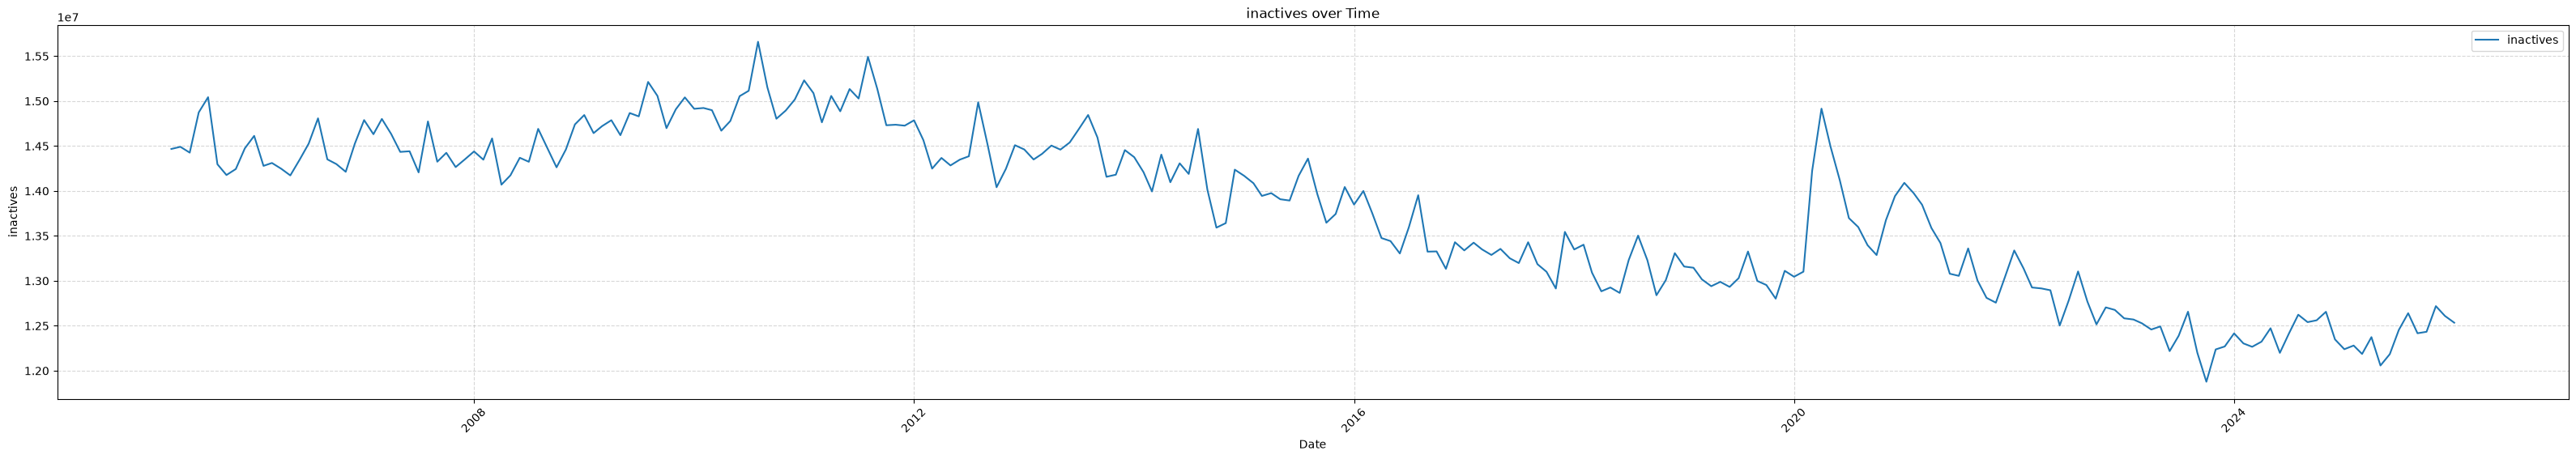

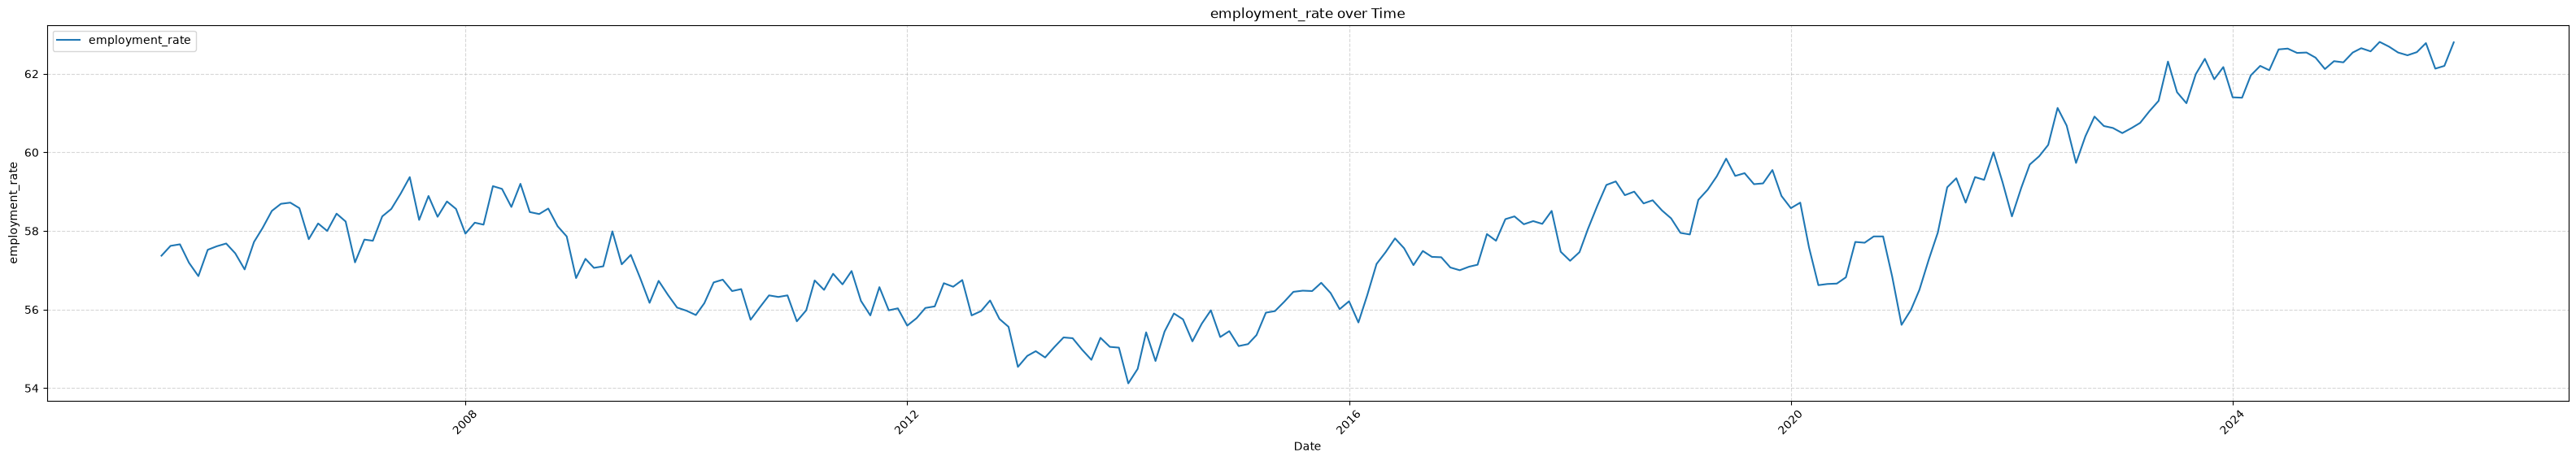

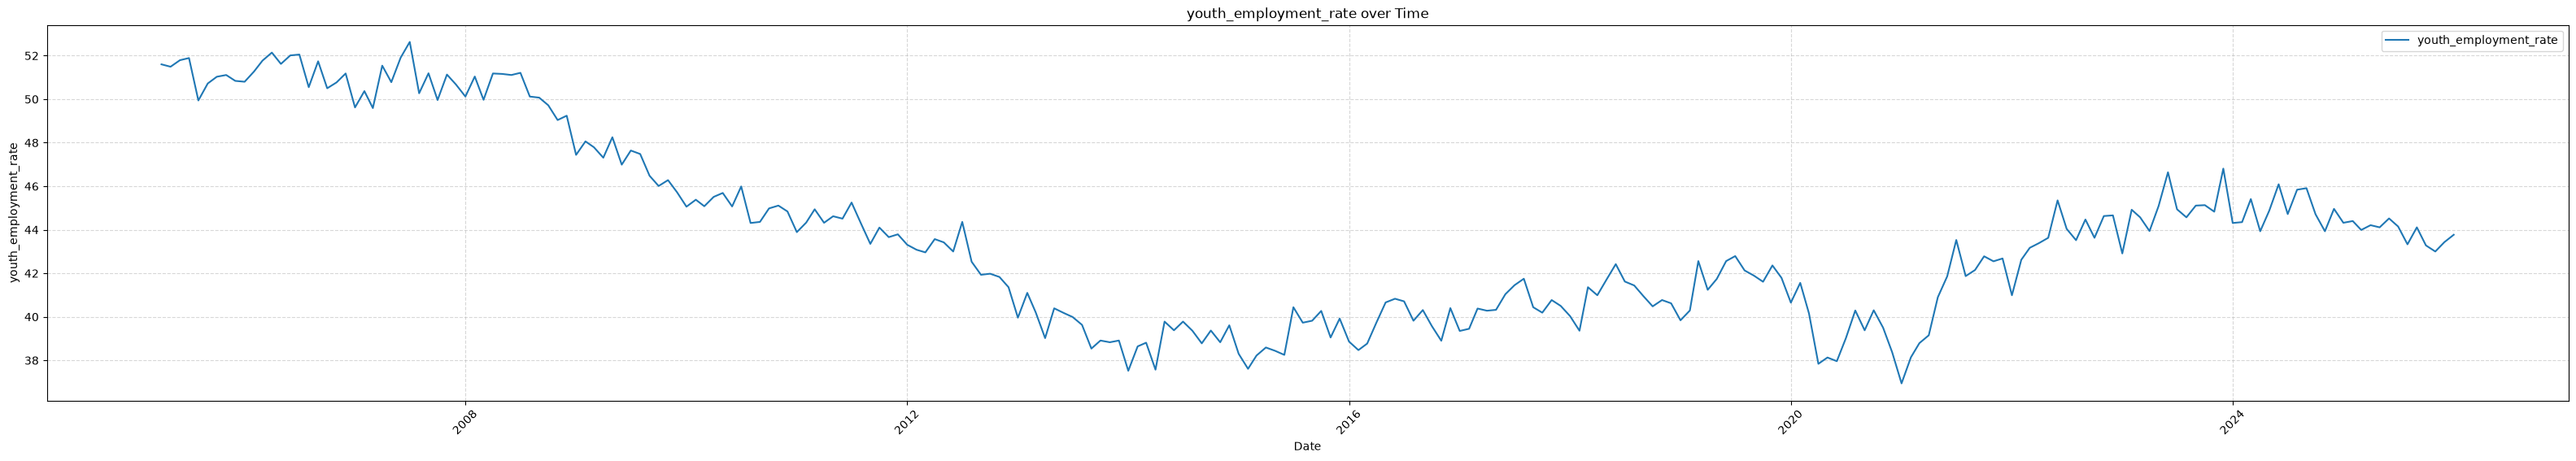

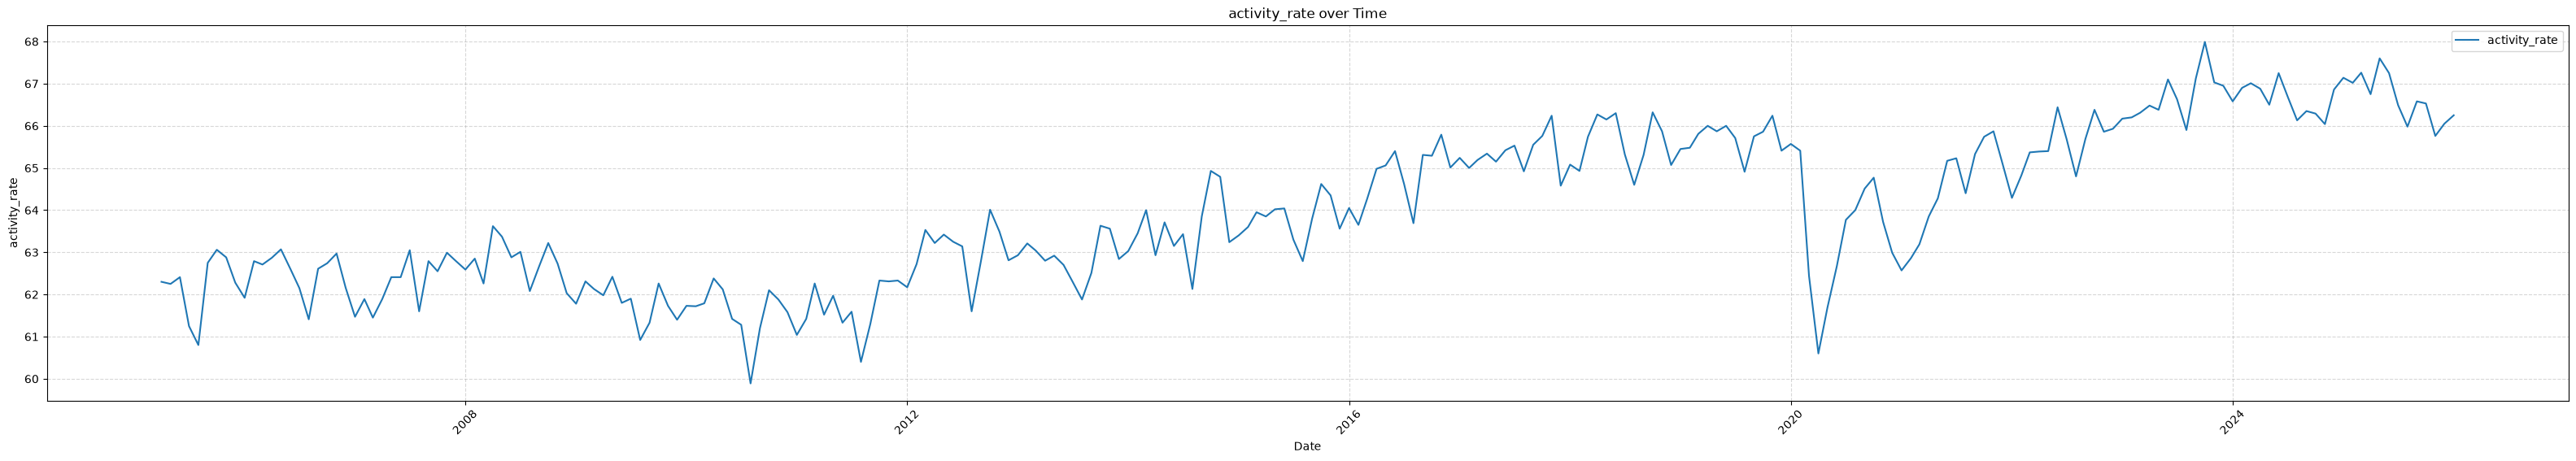

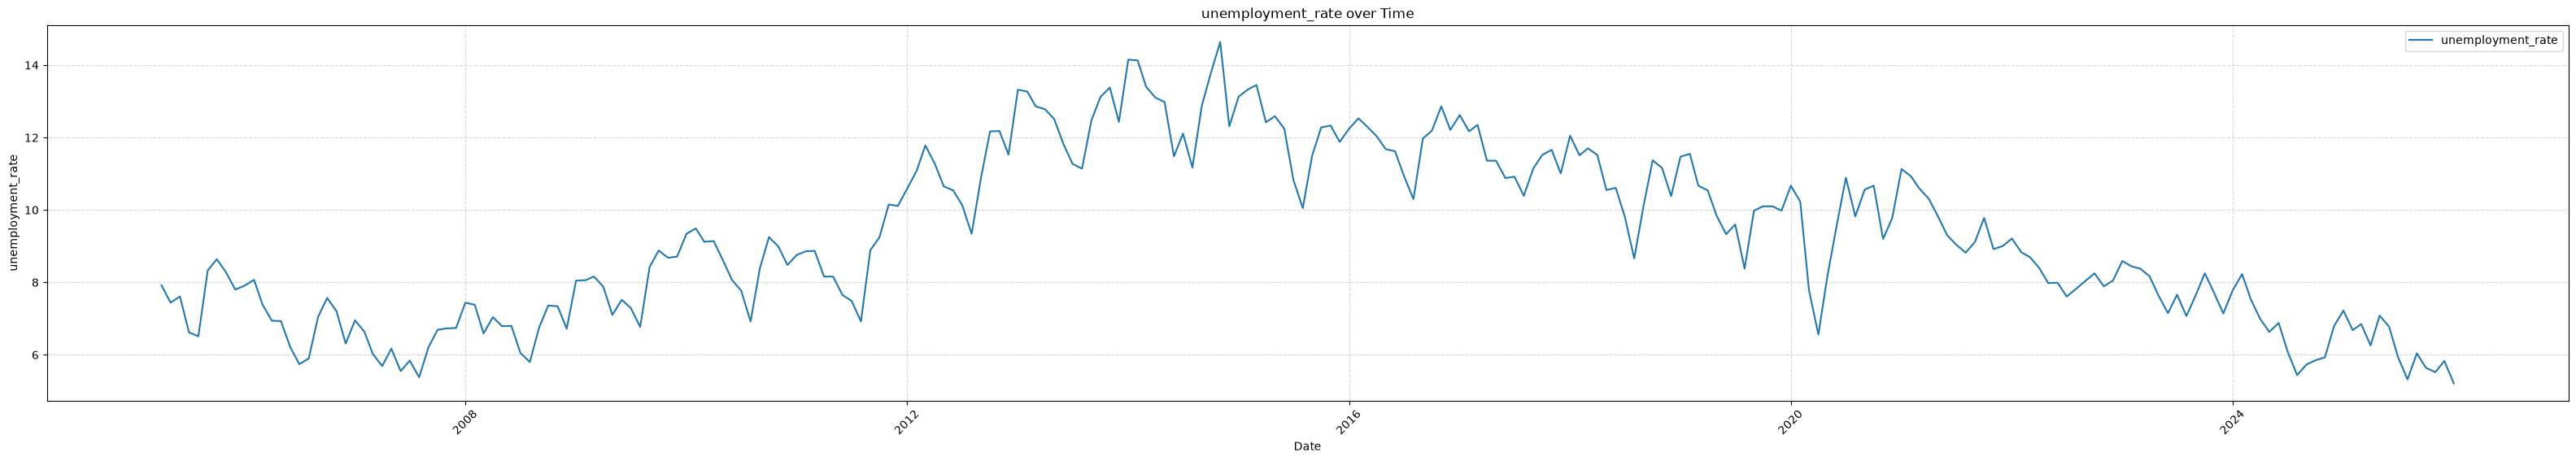

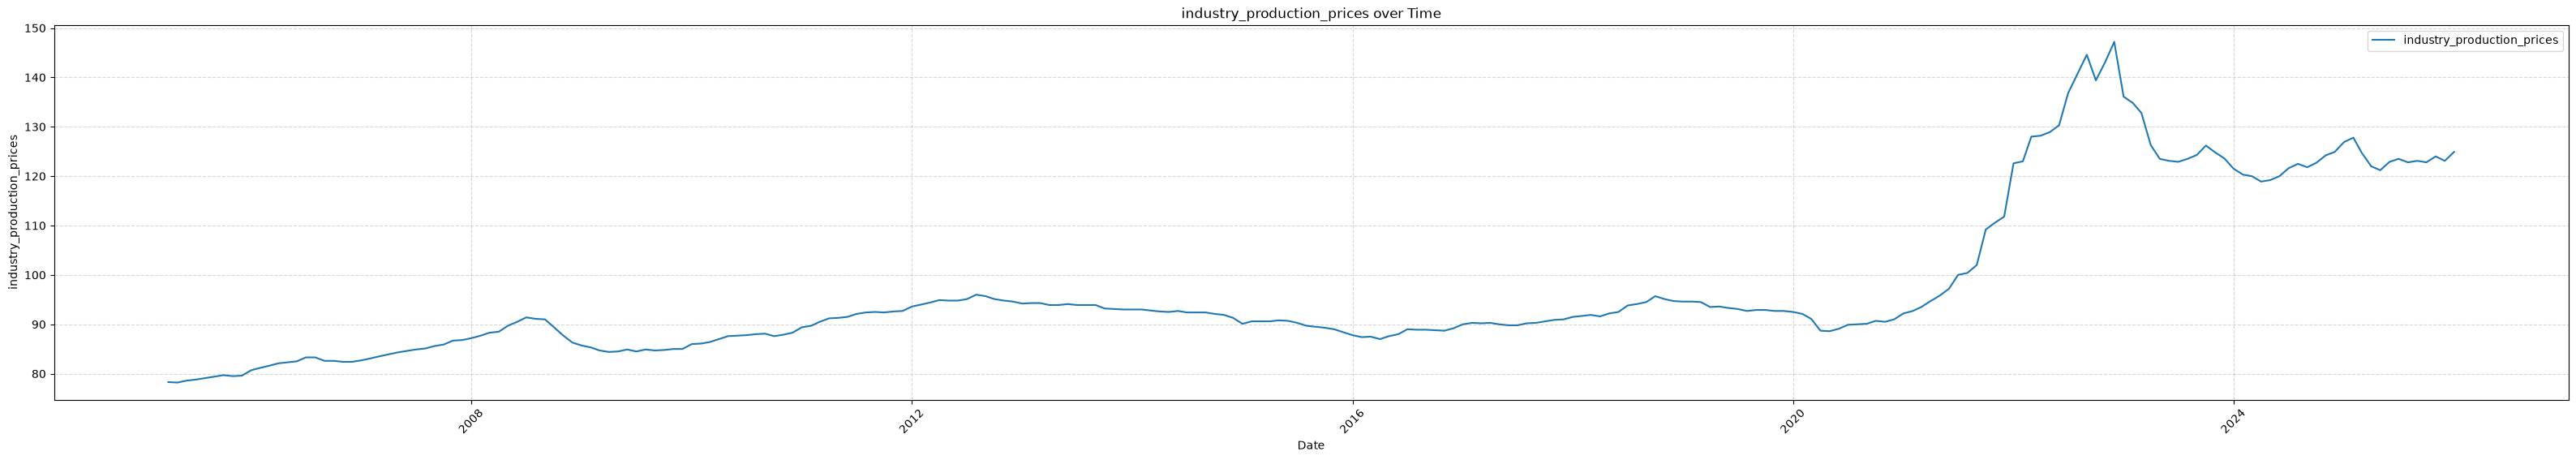

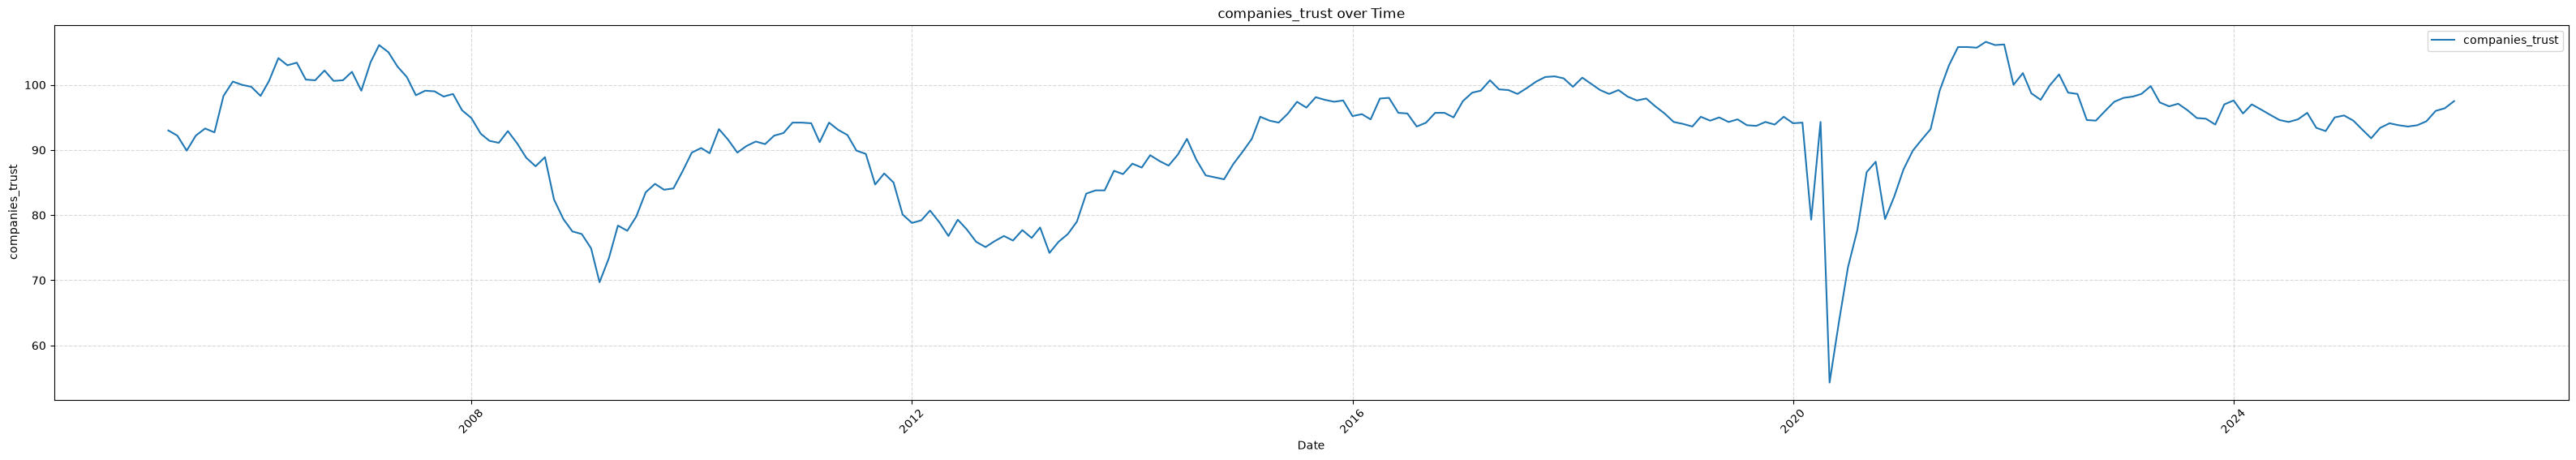

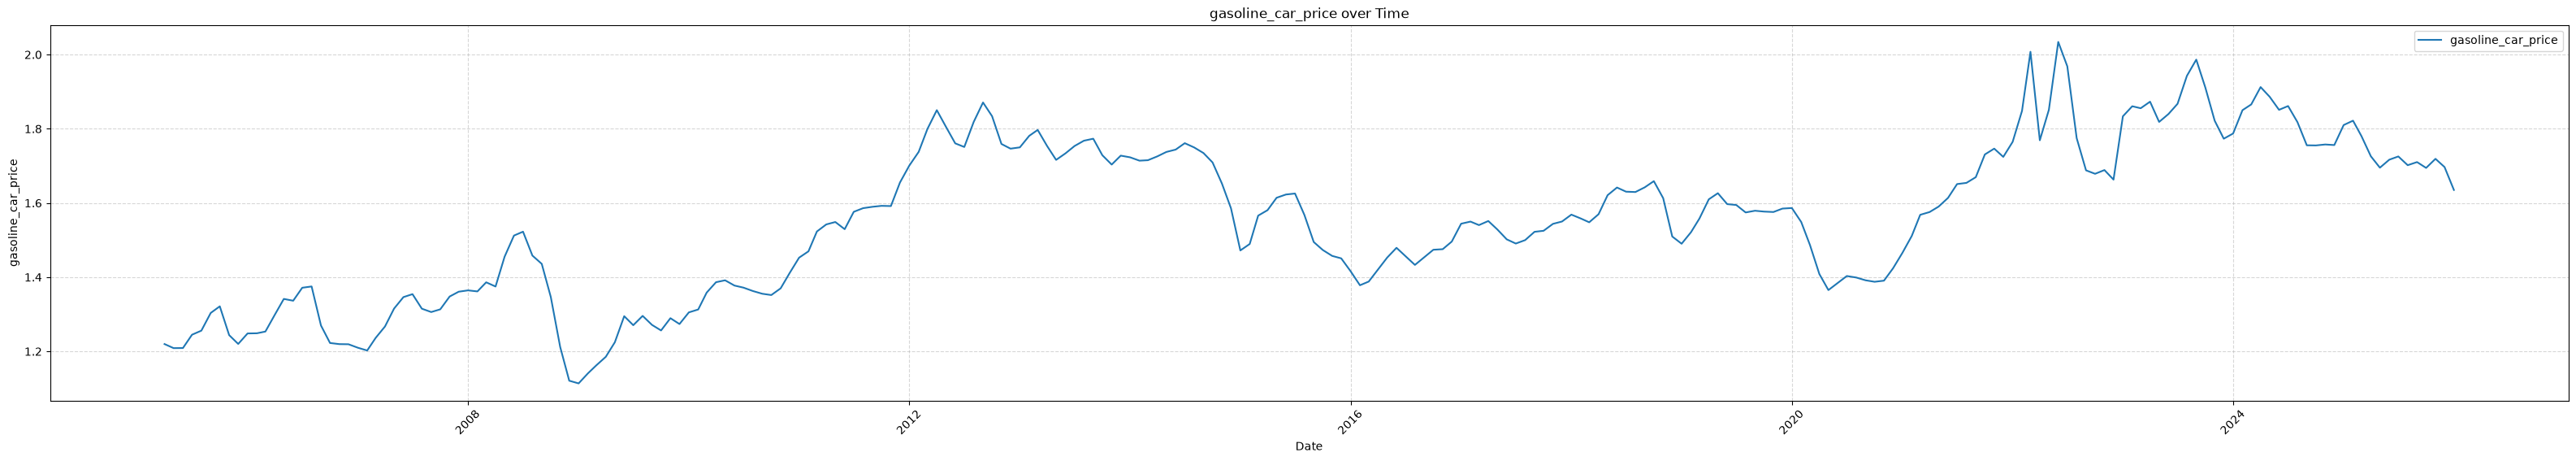

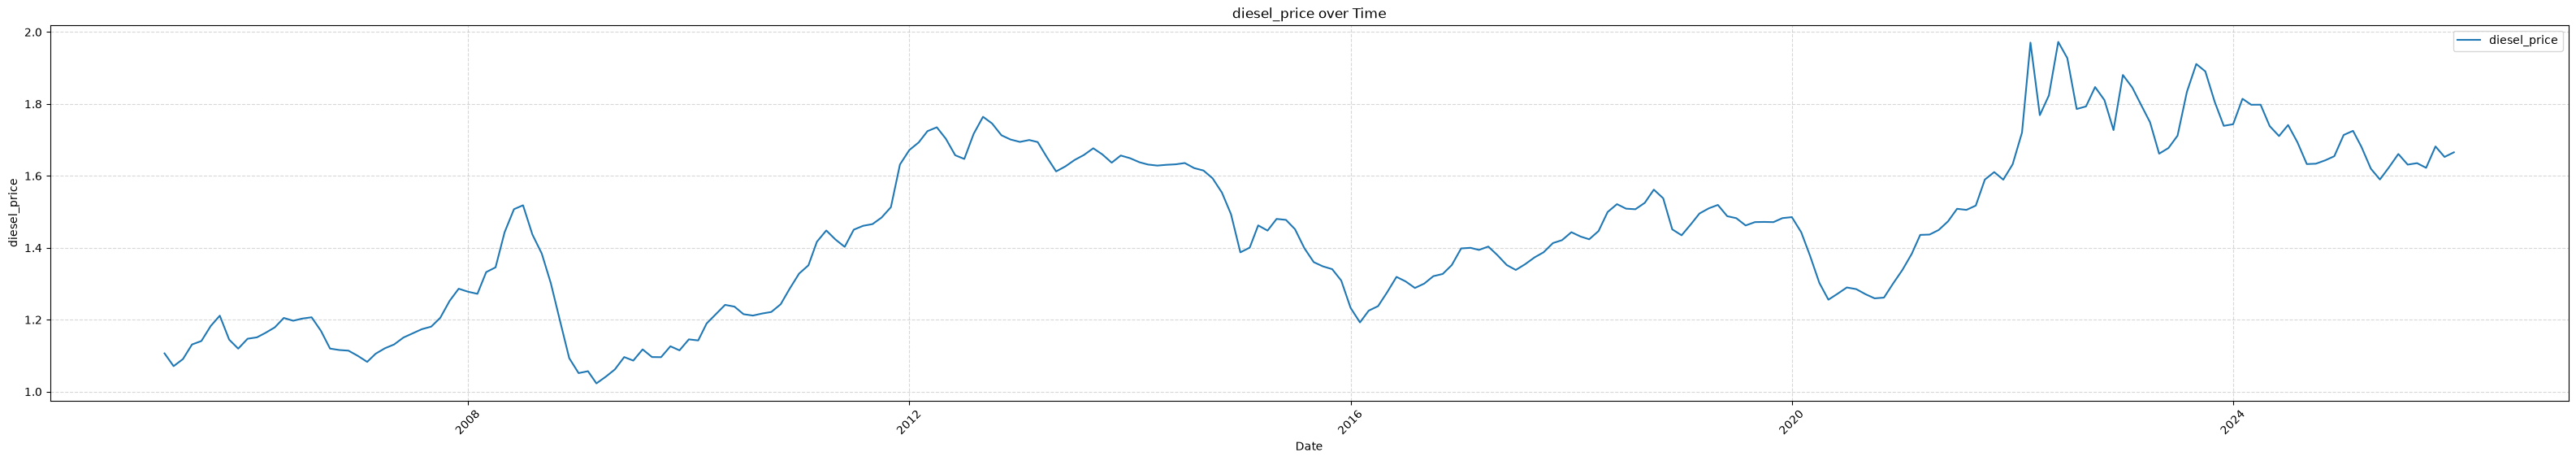

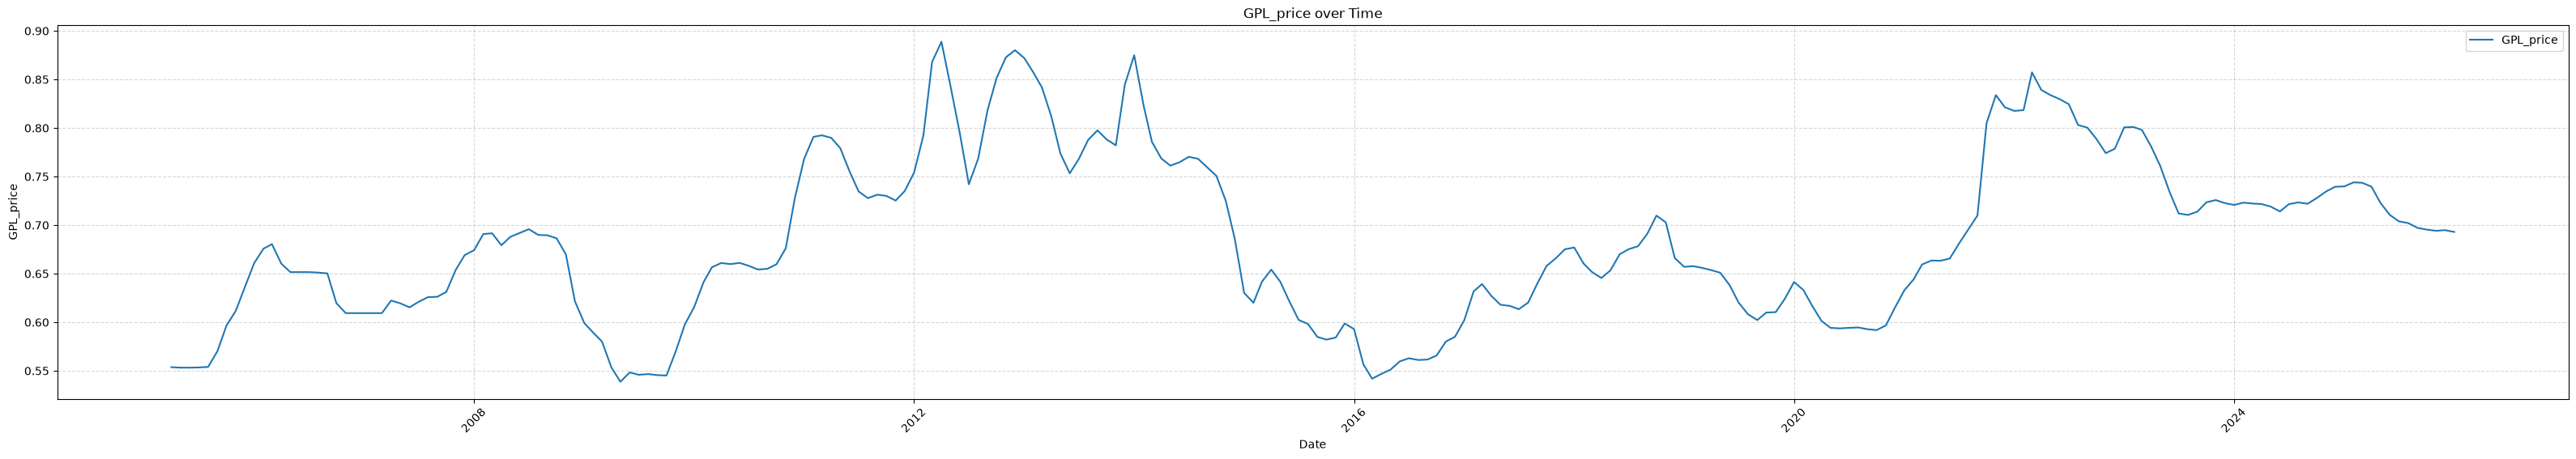

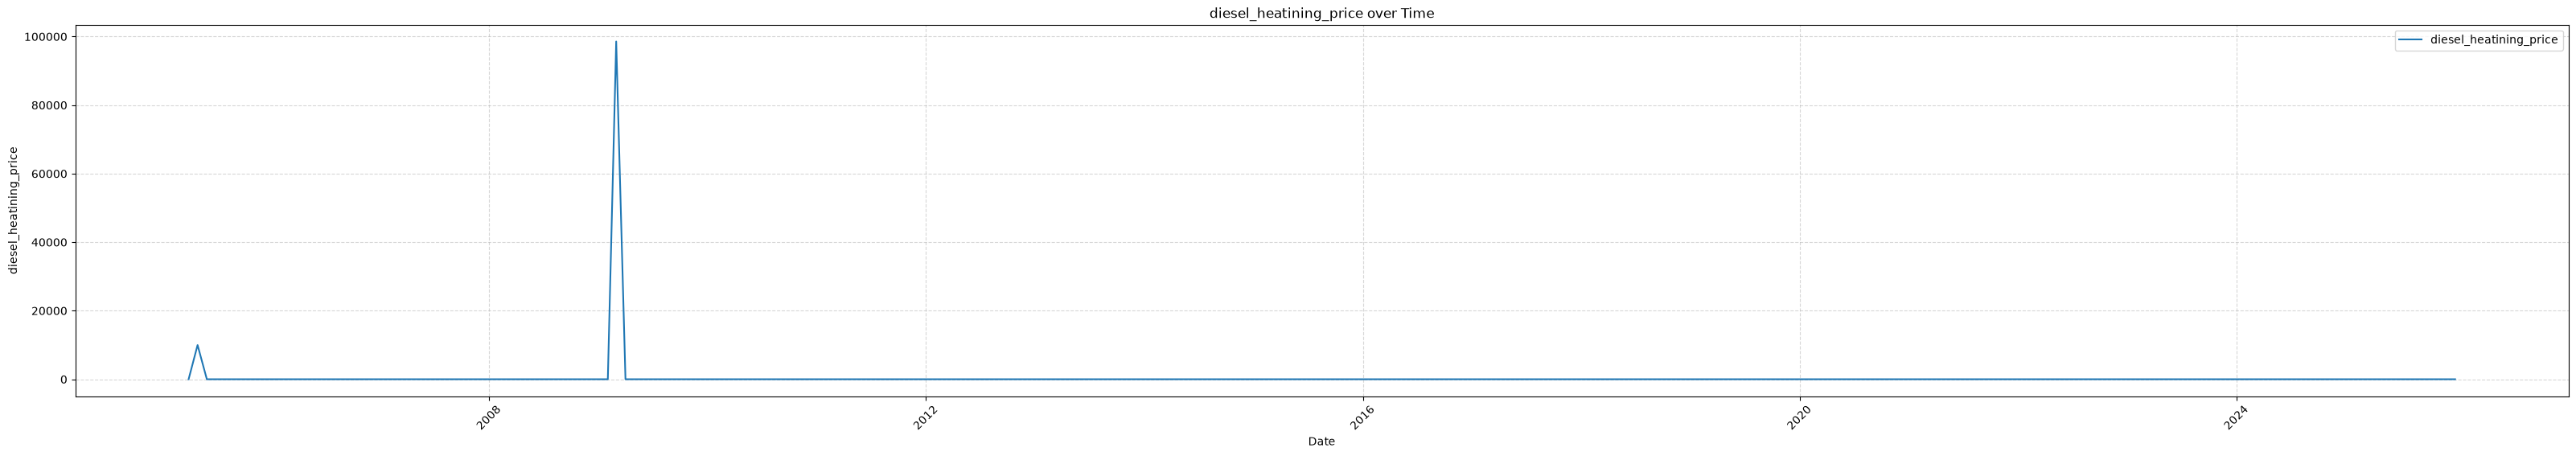

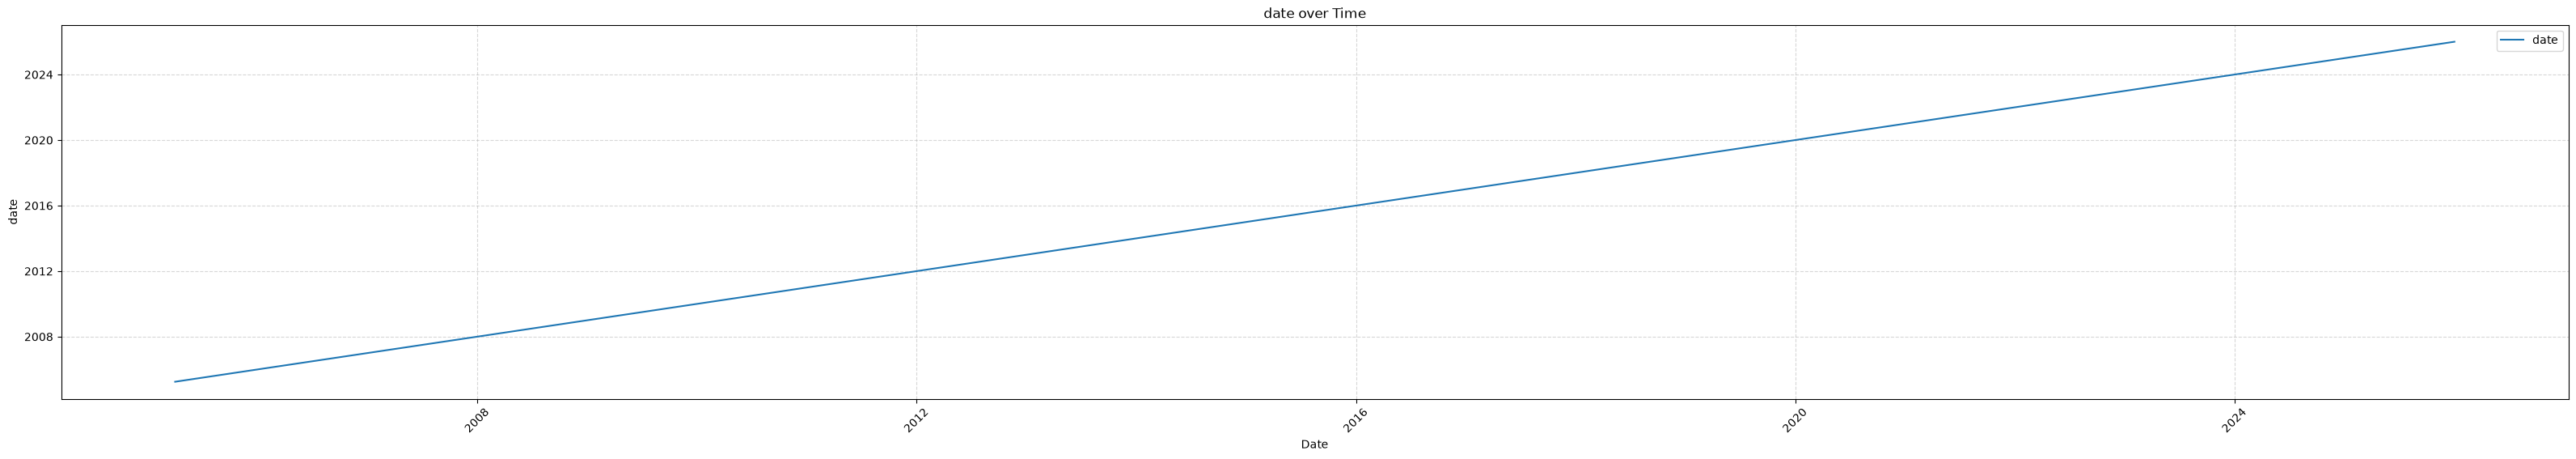

In [12]:
import matplotlib.dates as mdates

for col in numeric:
    plt.figure(figsize=(40, 6))
    
    # Create lineplot
    sns.lineplot(data=df_merged, x='date', y=col, label = col)
 
    plt.xticks(rotation=45)
    
    # Add title and labels
    plt.title(f'{col} over Time')
    plt.xlabel('Date')
 
    plt.grid(True, linestyle='--', alpha=0.5)
 
    plt.show()

## 1.1.1 Features creation

In [13]:
# df_merged['covid_period'] = ((df_merged['date']>= pd.Timestamp('2020-03-01')) &
#                               (df_merged['date']<= pd.Timestamp('2021-05-31'))).astype(int)

# df_merged['ukraine_war'] = (df_merged['date']> pd.Timestamp('2022-02-01')).astype(int)

## 1.2 ADF test: looking for stationarity

In [14]:
numeric_cols  =[ #'working_days', 
                'workforce', 
                    'inactives', 
                    'employment_rate',
                    # 'youth_employment_rate',
                    'activity_rate', 'unemployment_rate',
                    'industry_production_prices', 
                    'companies_trust', 
                    'gasoline_car_price',
                    'diesel_price', 
                    'GPL_price', 
                    'diesel_heatining_price']

In [15]:
df_merged.isnull().sum()

date                          0
workforce                     0
inactives                     0
employment_rate               0
youth_employment_rate         0
activity_rate                 0
unemployment_rate             0
industry_production_prices    0
companies_trust               0
gasoline_car_price            0
diesel_price                  0
GPL_price                     0
diesel_heatining_price        0
dtype: int64

In [16]:
stationary_cols = []
non_stationary_cols = []

for col in numeric_cols:
    print('---------------------------------------------')
    print(col)
    print('---------------------------------------------')

    test_staticist = adfuller(df_merged[col])[0]
    adf_criticatical_value_5perc = adfuller(df_merged[col])[4]['5%']
    if test_staticist > adf_criticatical_value_5perc:
        non_stationary_cols.append(col)
        print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
        df_merged[f'{col}_diff'] = df_merged[col] - df_merged[col].shift( 1) # qui facciamo subito la differnziazione

    else:
        stationary_cols.append(col)
        print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')

---------------------------------------------
workforce
---------------------------------------------
-2.51 > -2.87 ==> The time series is NON stationary
---------------------------------------------
inactives
---------------------------------------------
-0.91 > -2.87 ==> The time series is NON stationary
---------------------------------------------
employment_rate
---------------------------------------------
-0.54 > -2.87 ==> The time series is NON stationary
---------------------------------------------
activity_rate
---------------------------------------------
-1.34 > -2.87 ==> The time series is NON stationary
---------------------------------------------
unemployment_rate
---------------------------------------------
-1.16 > -2.87 ==> The time series is NON stationary
---------------------------------------------
industry_production_prices
---------------------------------------------
-1.29 > -2.87 ==> The time series is NON stationary
-----------------------------------------

In [17]:
df_merged[[ 'date'] + stationary_cols + non_stationary_cols].to_csv("dataset_FINAL_not_differentiated.csv", index = False)

In [18]:
df_merged.columns

Index(['date', 'workforce', 'inactives', 'employment_rate',
       'youth_employment_rate', 'activity_rate', 'unemployment_rate',
       'industry_production_prices', 'companies_trust', 'gasoline_car_price',
       'diesel_price', 'GPL_price', 'diesel_heatining_price', 'workforce_diff',
       'inactives_diff', 'employment_rate_diff', 'activity_rate_diff',
       'unemployment_rate_diff', 'industry_production_prices_diff',
       'companies_trust_diff', 'gasoline_car_price_diff', 'diesel_price_diff',
       'GPL_price_diff'],
      dtype='str')

# Differeziazione

In [19]:
non_stationary_cols = [
                # 'working_days',
                'workforce',
                'inactives',
                'employment_rate',
                # 'youth_employment_rate',
                'activity_rate',
                'industry_production_prices',
                'gasoline_car_price',
                'diesel_price',
                'diesel_heatining_price',
                'unemployment_rate'
                ]

diff_cols=[#'working_days_diff',
           'workforce_diff',  
           'inactives_diff', 
           'employment_rate_diff', 
        #    'youth_employment_rate_diff',
          'activity_rate_diff', 
          'industry_production_prices_diff', 
          'gasoline_car_price_diff', 
          'diesel_price_diff',
          # 'diesel_heatining_price_diff',
          'unemployment_rate_diff' ]

In [20]:
df_merged_detrended =  df_merged[['date',   
                                  # 'working_days_diff',
                                    'workforce_diff', 
                                    'inactives_diff', 
                                    # 'employment_rate', 
                                    'employment_rate_diff', 
                                    'activity_rate_diff', 
                                    'industry_production_prices_diff',
                                    'companies_trust',  
                                    'gasoline_car_price_diff', 
                                    'diesel_price_diff',  
                                    'GPL_price',  
                                    'diesel_heatining_price',
                                    # 'diesel_heatining_price_diff', 
                                    'unemployment_rate', 
                                    'unemployment_rate_diff'
                                    # 'covid_period', 
                                    # 'ukraine_war'
                                    ]]

## 1.3 ACF and PACF plot

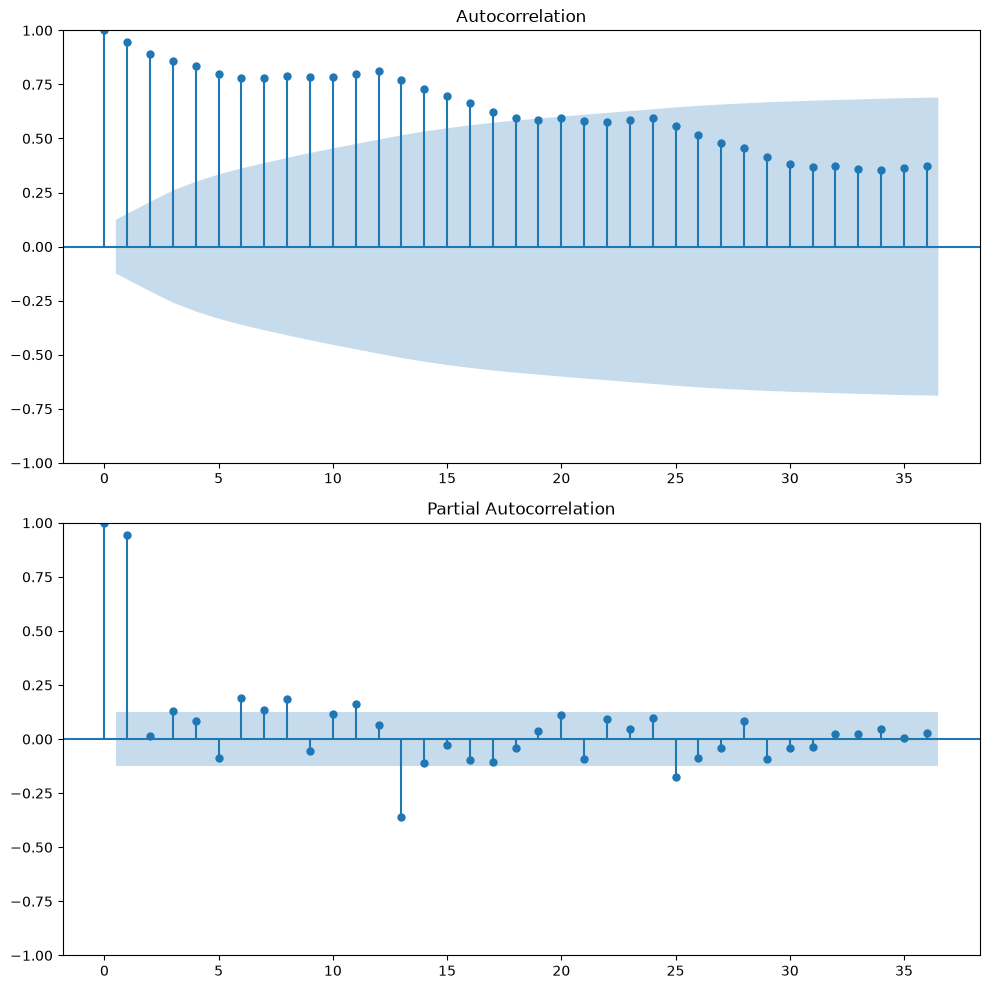

In [21]:
width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df_merged_detrended['unemployment_rate'],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df_merged_detrended['unemployment_rate'],lags=36, ax=ax[1], alpha=0.05, method="ywm")


plt.tight_layout()
plt.show()

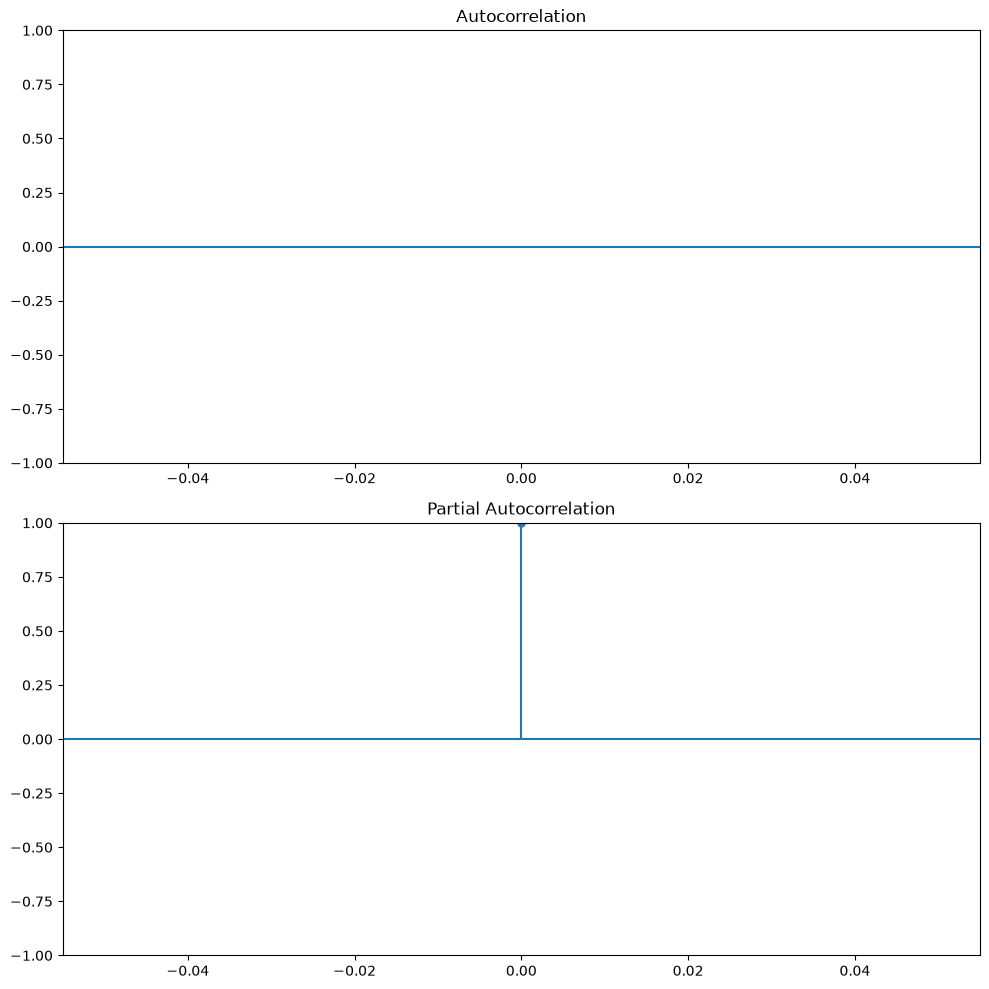

In [22]:
width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df_merged_detrended['unemployment_rate_diff'],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df_merged_detrended['unemployment_rate_diff'],lags=36, ax=ax[1], alpha=0.05, method="ywm")


plt.tight_layout()
plt.show()

## 1.4 Rolling and Lagged features

In [23]:
df_merged_detrended['rolling_mean_3m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=3).mean()
df_merged_detrended['rolling_mean_6m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=6).mean()
df_merged_detrended['rolling_mean_12m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=12).mean()
df_merged_detrended['rolling_std_12m'] = df_merged_detrended['unemployment_rate_diff'].rolling(window=12).std()

df_merged_detrended['lag_1m'] = df_merged_detrended['unemployment_rate_diff'].shift(1)
df_merged_detrended['lag_2m'] = df_merged_detrended['unemployment_rate_diff'].shift(2)
df_merged_detrended['lag_3m'] = df_merged_detrended['unemployment_rate_diff'].shift(3)
df_merged_detrended['lag_12m'] = df_merged_detrended['unemployment_rate_diff'].shift(12)


# Uncertainty coefficient

In [24]:
def _validate_and_crosstab(x, y):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return None
    pxy_table = pd.crosstab(df["x"], df["y"], normalize='all')
    if pxy_table.size == 0 or pxy_table.values.sum() == 0:
        return None
    return pxy_table.to_numpy(dtype=float)
 
def uncertainty_coefficients(x,y,base = 2):
    """Compute Theil's U between two categorical variables.
   
    Params
    ------
    x, y: array-like (categorical, string, or discrete)
          Variables of equal length. NaN pairs are dropped pairwise.
    base: float, optional (default = 2)
          Logarithm base for the entropy.
         
    Returns
    -------
    dict with keys:
        - 'U_X_given_Y' : U(X | Y) = I(X;Y) / H(X)
        - 'U_Y_given_X' : U(Y | X) = I(X;Y) / H(Y)
        - 'U_symmetric' : 2 * I(X;Y) / (H(X) + H(Y))   (0 if both entropies are 0)
 
    Notes
    -----
    I(X;Y) = H(X) + H(Y) - H(X,Y)
    H(X|Y) = H(X,Y) - H(Y)
    When H(X)=0 (or H(Y)=0), the corresponding asymmetric U is defined as 0.0.
    """
    pxy = _validate_and_crosstab(x, y)
    if pxy is None:
        return {"U_X_given_Y": np.nan, "U_Y_given_X": np.nan, "U_symmetric": np.nan}
   
    px = pxy.sum(axis = 1)
    py = pxy.sum(axis = 0)
   
    Hx = entropy(px, base=base)
    Hy = entropy(py, base=base)
    Hxy = entropy(pxy.ravel(), base=base)
   
    Ixy = Hx + Hy - Hxy
   
    U_x_given_y = 0.0 if np.isclose(Hx,0.0) else Ixy / Hx
    U_y_given_x = 0.0 if np.isclose(Hy,0.0) else Ixy / Hy
   
    den = Hx + Hy
    U_sym = 0.0 if np.isclose(den, 0.0) else (2.0 * Ixy) / den
   
    return {"U_X_given_Y": U_x_given_y, "U_Y_given_X": U_y_given_x, "U_symmetric": U_sym}
 
def pairwise_uncertainty(df, cols = None, base=2, symmetric=False):
    """Compute a pairwise matrix of Theil's uncertainty coefficients for a DataFrame.
   
    Params
    ------
        df: pandas.DataFrame
            The data. Non-categorical columns are allowed.
        cols: list-like or None
              Subset of cols to include. Defaults to all columns.
        base: float
              Entropy base (2 for bits)
        symmetric: bool
                   If True, returns the symmetric coefficient, else returns
                   U(X|Y) with rows = X, cols = Y.
   
    Returns
    -------
    pandas.DataFrame
        Matrix of uncertainty coeffs.
    """
    if cols is None:
        cols = list(df.columns)
   
    cols = list(cols)
    res = pd.DataFrame(index=cols, columns=cols, dtype=float)
   
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                res.iloc[i,j] = 1
                continue
            coeffs = uncertainty_coefficients(df[c1], df[c2], base=base)
            res.iloc[i,j] = coeffs["U_symmetric"] if symmetric else coeffs["U_X_given_Y"]
   
    return res
 

In [25]:
cols_coeff = ['date',  
            #   'working_days_diff',
              'workforce_diff', 
              'inactives_diff',
              'employment_rate_diff', #'youth_employment_rate_diff',
              'activity_rate_diff', 
              'industry_production_prices_diff', 
              'companies_trust',
              'gasoline_car_price_diff', 
              'diesel_price_diff', 
              'GPL_price',
              # 'diesel_heatining_price_diff',
              'unemployment_rate_diff']

In [26]:
df_to_corr = df_merged_detrended[df_merged_detrended['date']<= '2025/07/01']
df_to_corr = df_to_corr[cols_coeff]

df_unc_corr = pairwise_uncertainty(df_to_corr)


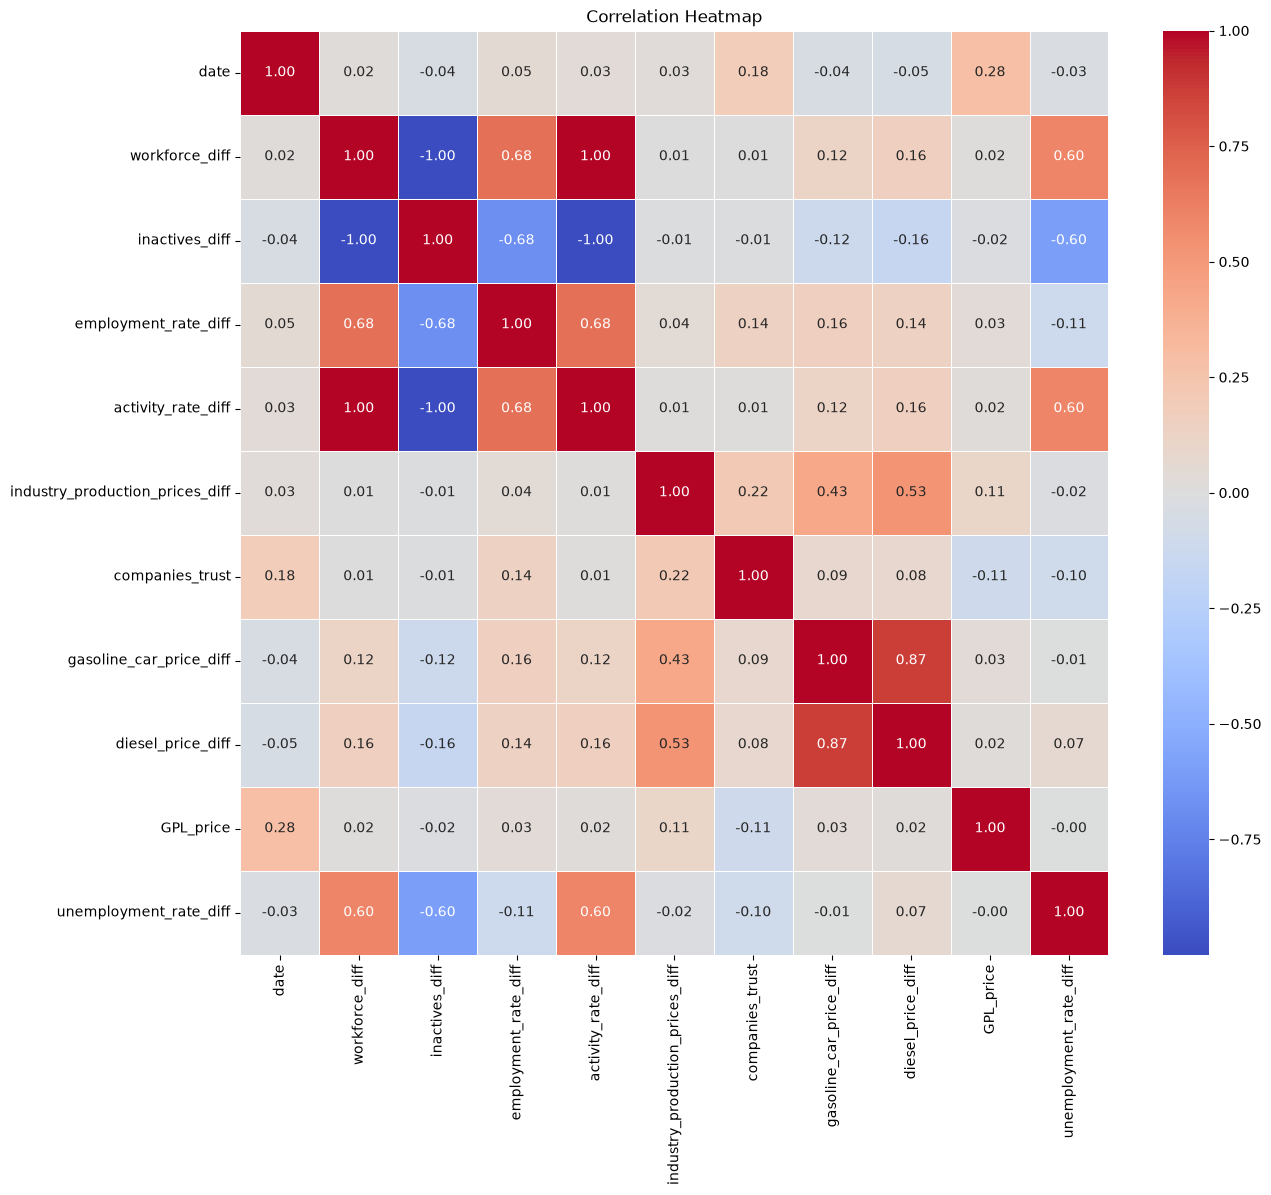

In [28]:
matrix = df_to_corr.corr(method = 'spearman')

plt.figure(figsize=(14,12))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# PCA

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [30]:
df_merged_detrended = df_merged_detrended.iloc[13:] # questo serve a togliere le prime 13 righe che hanno dei valori NUll

In [31]:
df_merged_detrended[df_merged_detrended[ 'workforce_diff'].isnull()==True]
                    #  , 'inactives_diff','activity_rate_diff']].isnull().sum()

,date,workforce_diff,inactives_diff,employment_rate_diff,activity_rate_diff,industry_production_prices_diff,companies_trust,gasoline_car_price_diff,diesel_price_diff,GPL_price,...,unemployment_rate,unemployment_rate_diff,rolling_mean_3m,rolling_mean_6m,rolling_mean_12m,rolling_std_12m,lag_1m,lag_2m,lag_3m,lag_12m


In [32]:
X_labour_market = df_merged_detrended[[  'workforce_diff', 'inactives_diff',
                                            'activity_rate_diff']]

X_price_energy = df_merged_detrended[[ 'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price'
                                       ,'diesel_heatining_price'
                                    #    ,'diesel_heatining_price_diff'
                                      ]]

# X_macroeconomic_variables = df_merged_detrended[[  'industry_production_prices_diff', 'companies_trust' ]]

scaler = StandardScaler()
X_labour_market_scaled = scaler.fit_transform(X_labour_market)
X_price_energy_scaled = scaler.fit_transform(X_price_energy)
# X_macroeconomic_variables_scaled = scaler.fit_transform(X_macroeconomic_variables)

In [33]:
X_labour_market.isnull().sum()

workforce_diff        0
inactives_diff        0
activity_rate_diff    0
dtype: int64

In [34]:
pca = PCA(n_components=2)
df_merged_detrended[['PCA_labour_market_1', 'PCA_labour_market_2']] = pca.fit_transform(X_labour_market_scaled)
df_merged_detrended[['PCA_price_energy_1', 'PCA_price_energy_2']] = pca.fit_transform(X_price_energy)
# df_merged_detrended[['PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2']] = pca.fit_transform(X_macroeconomic_variables)

# Final

In [37]:
df_merged_detrended = df_merged_detrended[['date', 
                                        #    'working_days_diff',
                                        #    'workforce_diff', 
                                        #    'inactives_diff',
                                        #     'activity_rate_diff', 
                                            'employment_rate_diff', 
                                            'industry_production_prices_diff', 
                                            'companies_trust',
                                            # 'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
                                            # 'diesel_heatining_price_diff',
                                            'rolling_mean_3m', 
                                            'rolling_mean_6m',
                                            'rolling_mean_12m', 
                                            'rolling_std_12m', 
                                            # 'lag_1m', 
                                            # 'lag_2m', 
                                            # 'lag_3m', 
                                            # 'lag_12m', 
                                            'PCA_labour_market_1', 
                                            'PCA_labour_market_2',
                                            'PCA_price_energy_1', 
                                            'PCA_price_energy_2',
                                            'unemployment_rate', 
                                            'unemployment_rate_diff',
                                            ]]

In [39]:
from datetime import datetime as dt

In [40]:
df_merged_detrended['month'] = df_merged_detrended['date'].dt.month
df_merged_detrended['year'] = df_merged_detrended['date'].dt.year

In [41]:
df_missing_cols = df_merged_detrended[['date','year', 'month','PCA_labour_market_1', 'PCA_labour_market_2',  
                                     'PCA_price_energy_1', 'PCA_price_energy_2', 
                                    #   'lag_12m', 'lag_1m', 'lag_2m', 'lag_3m',
                                      'rolling_mean_3m',  
                                      'rolling_mean_6m', 
                                      'rolling_mean_12m', 
                                      'rolling_std_12m']]

In [42]:
df_final = df_merged.merge(df_missing_cols, how ='inner', on = 'date')
df_final.columns

Index(['date', 'workforce', 'inactives', 'employment_rate',
       'youth_employment_rate', 'activity_rate', 'unemployment_rate',
       'industry_production_prices', 'companies_trust', 'gasoline_car_price',
       'diesel_price', 'GPL_price', 'diesel_heatining_price', 'workforce_diff',
       'inactives_diff', 'employment_rate_diff', 'activity_rate_diff',
       'unemployment_rate_diff', 'industry_production_prices_diff',
       'companies_trust_diff', 'gasoline_car_price_diff', 'diesel_price_diff',
       'GPL_price_diff', 'year', 'month', 'PCA_labour_market_1',
       'PCA_labour_market_2', 'PCA_price_energy_1', 'PCA_price_energy_2',
       'rolling_mean_3m', 'rolling_mean_6m', 'rolling_mean_12m',
       'rolling_std_12m'],
      dtype='str')

In [43]:
df_final = df_merged.merge(df_missing_cols, how ='inner', on = 'date')
df_final.to_csv("dataset_FINAL_all_variables.csv", index=False)